In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
from matplotlib import pylab as pl
from matplotlib import cm
from matplotlib import rcParams
import numpy as np
import pandas as pd
import edson

import sys
sys.path.insert(0, "../sliptools")
from statData import StatData

nu = 1.8e-5

In [2]:
def make_statlist(caseids, ids, case_info):
    time_window = [0,10]
    dirname = ''

    statlist = {}
    for id, case in zip(ids, caseids):
            casename = case.split('/')[0]
            cinf = case_info.loc[casename]
            stat_params = cinf.to_dict()
            fname = dirname+casename+'.txt'
            statlist[id] = StatData(fname, ustar=stat_params['ustar_mean'])
            # statlist[id] = StatData.PVstat(id, case, params=stat_params, dirname=dirname, 
            #                             time_index=1, time_window=time_window,
            #                             save_mean=False, read_save=True)
    
    return statlist

In [3]:
def plot_velocity(stats, ids, colors, linestyle='-', axs=[], labels=True):
    if len(axs) == 0:
        fig, axs = plt.subplots(1,2,facecolor='w', dpi=180.0, tight_layout=True, figsize=(8,4))

    for i in range(len(ids)):
        id = ids[i]
        u = stats[id].data['U']
        y = stats[id].data['ym']

        if labels:
            axs[0].plot(u, y, lw=2, color=colors[i], ls=linestyle, label=id)
        else:
            axs[0].plot(u, y, lw=2, color=colors[i], ls=linestyle)
        
        # * viscous scaling
        ustar = stats[id].ustar
        H = 1000

        axs[1].plot(y[1:]/H, u[1:]/ustar, marker='.', ls=linestyle,
                    color=colors[i], label=id)

    axs[0].set_ylim((0,1000))
    axs[0].set_xlabel('U (m/s)')
    axs[0].set_ylabel('y (m)')
    axs[0].legend()

    axs[1].set_ylabel(r'$\langle \overline{u}\rangle/u_\ast$')
    axs[1].set_xlabel(r'$y/H$')
    axs[1].set_xscale('log')
    axs[1].set_xlim((1e-3, 1))

    # return fig, axs

In [4]:
def plot_reynolds(stats, ids, colors, linestyle='-', fig=None, axs=None, labels=True):
    if not fig:
        fig, axs = plt.subplots(2, 3, facecolor='w', dpi=180, constrained_layout=True,
                                figsize=(10,6), sharey=True)

    plot_ids = ['up_up','vp_vp','wp_wp','up_vp','up_wp','vp_wp']
    plot_labels = [r"$\langle u'u'\rangle$", r"$\langle v'v'\rangle$",
                r"$\langle w'w'\rangle$", r"$\langle u'v'\rangle$",
                r"$\langle u'w'\rangle$", r"$\langle v'w'\rangle$"]
    
    for j in range(len(plot_ids)):
        axi = int(j/3)
        axj = j%3

        for i in range(len(ids)):
            id = ids[i]

            if labels:
                axs[axi,axj].plot(stats[id].data[plot_ids[j]],stats[id].data['ym'],
                        lw=1.2, color=colors[i], ls=linestyle, label=id)
            else:
                axs[axi,axj].plot(stats[id].data[plot_ids[j]],stats[id].data['ym'],
                    lw=1.2, color=colors[i], ls=linestyle)
            
        if axj == 0:   
            axs[axi,axj].set_ylabel(r'$y$')
        axs[axi,axj].set_title(plot_labels[j])

        axs[axi,axj].set_ylim((0,1000))

    axs[0,0].legend()


In [5]:
def plot_upvp(stats, ids, colors, ax=False, labels=True):
    if not ax:
        fig, ax = plt.subplots(1,1, facecolor='w', dpi=180, figsize=(5.2,4.6))

    for i in range(len(ids)):
        id = ids[i]
        ax.plot(stats[id].data['up_vp'], stats[id].data['y'],
                lw=2, color=colors[i], label=id)
    
    ax.set_xlabel(r"$\langle u'v' \rangle$")
    ax.set_ylabel(r'$y$')
    
    ax.set_ylim((0,1000))

    if labels:
        ax.legend()

In [6]:
def coare_plot_starter(figsize, Romero_cmap='none'):

    # * COARE 3.5 formula
    ncoare = 500
    u10_coare = np.linspace(1,20,ncoare)
    ustar_coare = np.empty(ncoare)

    for i in range(ncoare):
        if u10_coare[i] < 4:
            ustar_coare[i] = 0.03 * u10_coare[i]
        elif u10_coare[i] < 9.6:
            ustar_coare[i] = 0.035 * u10_coare[i] - 0.005*4
        else:
            # ustar_coare[i] = 0.058 * u10_coare[i] - 0.24 # Andreas et al. (2012)
            ustar_coare[i] = 0.062 * u10_coare[i] - 0.28

    fig, ax = plt.subplots(1,1,facecolor='w', dpi=180.0,tight_layout=True, figsize=figsize)

    # * Edson
    ed = edson.EdsonData()
    ed.fill_outer_region(ax)
    ed.fill_med_region(ax)
    plt.plot(u10_coare,ustar_coare,'k',lw=2.5,label='COARE 3.5', zorder=2)

    # * Romero
    rom = pd.read_csv('ext_data/romero.csv', header=0, sep=' ',index_col=False)
    rom['hs'] = 4*np.sqrt(rom['eta_sq'])
    if Romero_cmap == 'none':
        ax.scatter(rom['U10'],rom['ustar'],c='black',
                   s=5,label='Romero et al. 2010',zorder=2)
    else:
        rsc = ax.scatter(rom['U10'],rom['ustar'],c=rom['hs'],
                            cmap=Romero_cmap, vmin=0, vmax=4,
                            s=5,label='Romero et al. 2010',zorder=2)
        plt.colorbar(rsc, label='Romero Hs')

    ax.set_xlabel(r'$U_{10}$ (m/s)')
    ax.set_ylabel(r'$u_*$ (m/s)')

    ax.legend()

    ax.set_xlim((0,21.0))
    ax.set_ylim((0,1.2))

    return fig, ax

    

# Equilibrium vs. JONSWAP

### $H_s$ = 0.4

In [20]:
case_info = pd.read_excel('data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U18_HS04_kp07', 'HS04_js', 'HS04_js_match']
ids = ['Equilibrium', 'JONSWAP naive', 'JONSWAP matched']
colors = ['black', 'mediumseagreen', 'dodgerblue']

ids = ['HS04 '+id for id in ids]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

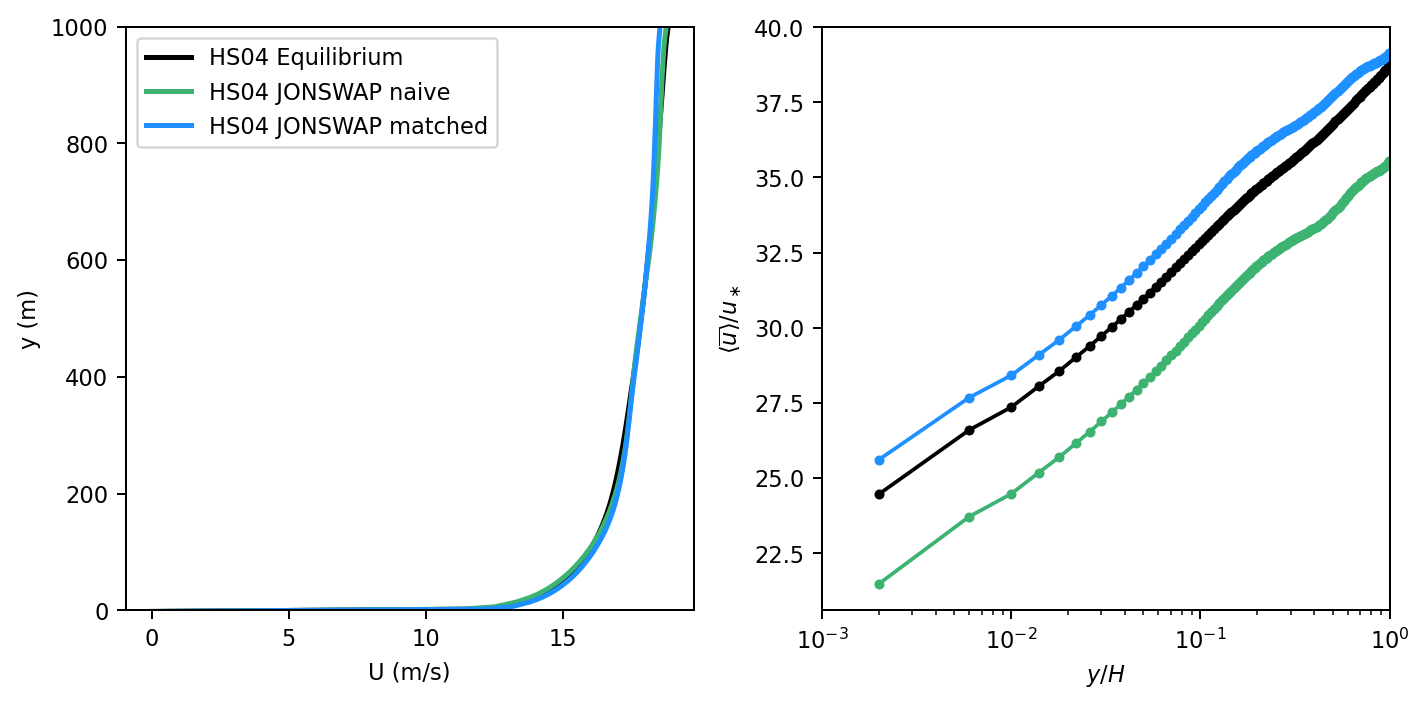

In [21]:
fig, axs = plt.subplots(1,2,facecolor='w', dpi=180.0, tight_layout=True, figsize=(8,4))

plot_velocity(statlist, ids, colors, axs=axs)

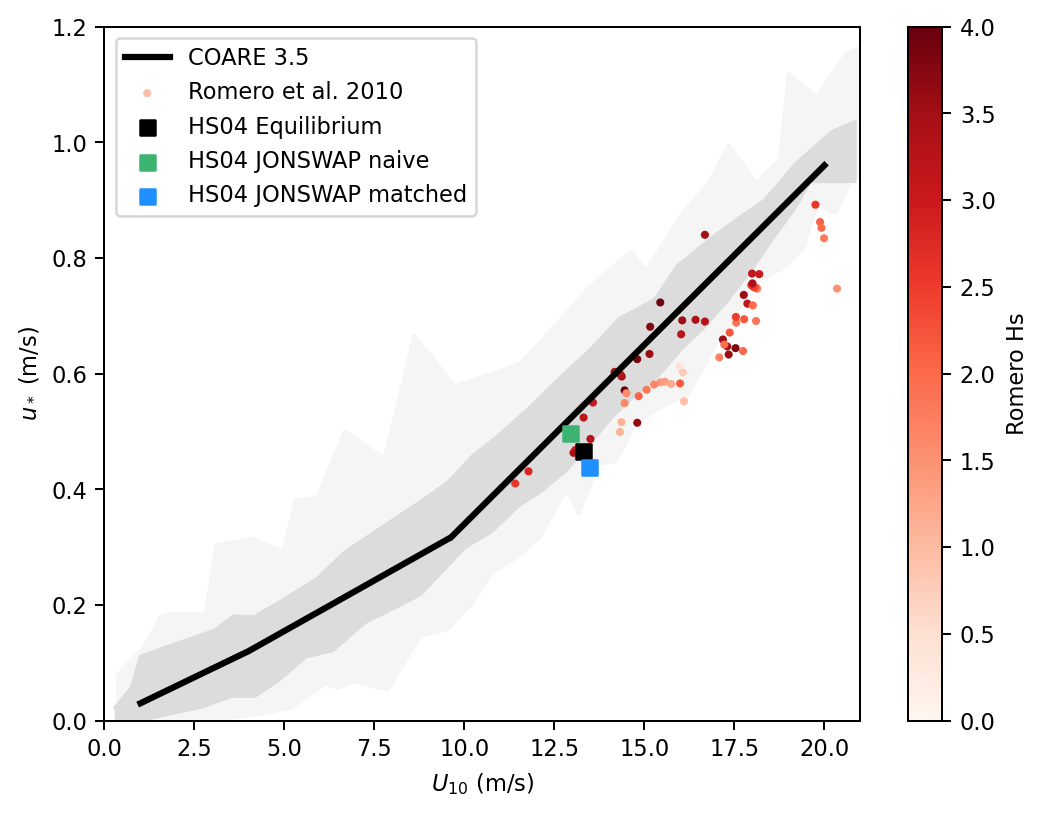

In [22]:
rcParams.update({'font.size': 9})
z_us = [2,100]

fig, ax = coare_plot_starter(figsize=(6,4.6), Romero_cmap='Reds')

hs_ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
hs_u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(statlist)):
    ax.scatter(hs_u10s[i], hs_ustars[i], c=colors[i], marker='s',
               label=ids[i], zorder=3)

ax.legend()

### $k_p$ = 0.0393

In [24]:
case_info = pd.read_excel('data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

cases = ['U18_HS12_kp04', 'kp04_js', 'kp04_js_match']
ids = ['Equilibrium', 'JONSWAP naive', 'JONSWAP matched']
colors = ['black', 'mediumseagreen', 'dodgerblue']

ids = ['kp04 '+id for id in ids]

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)

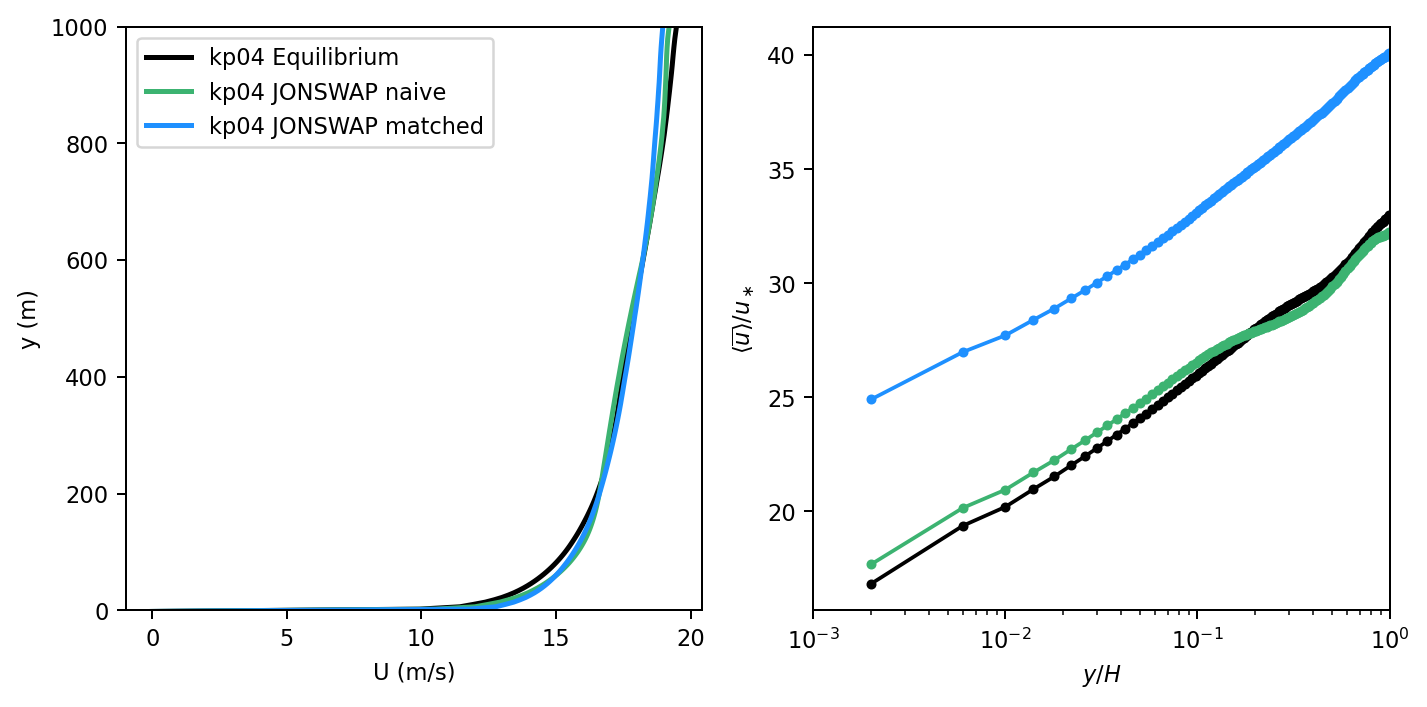

In [25]:
fig, axs = plt.subplots(1,2,facecolor='w', dpi=180.0, tight_layout=True, figsize=(8,4))

plot_velocity(statlist, ids, colors, axs=axs)

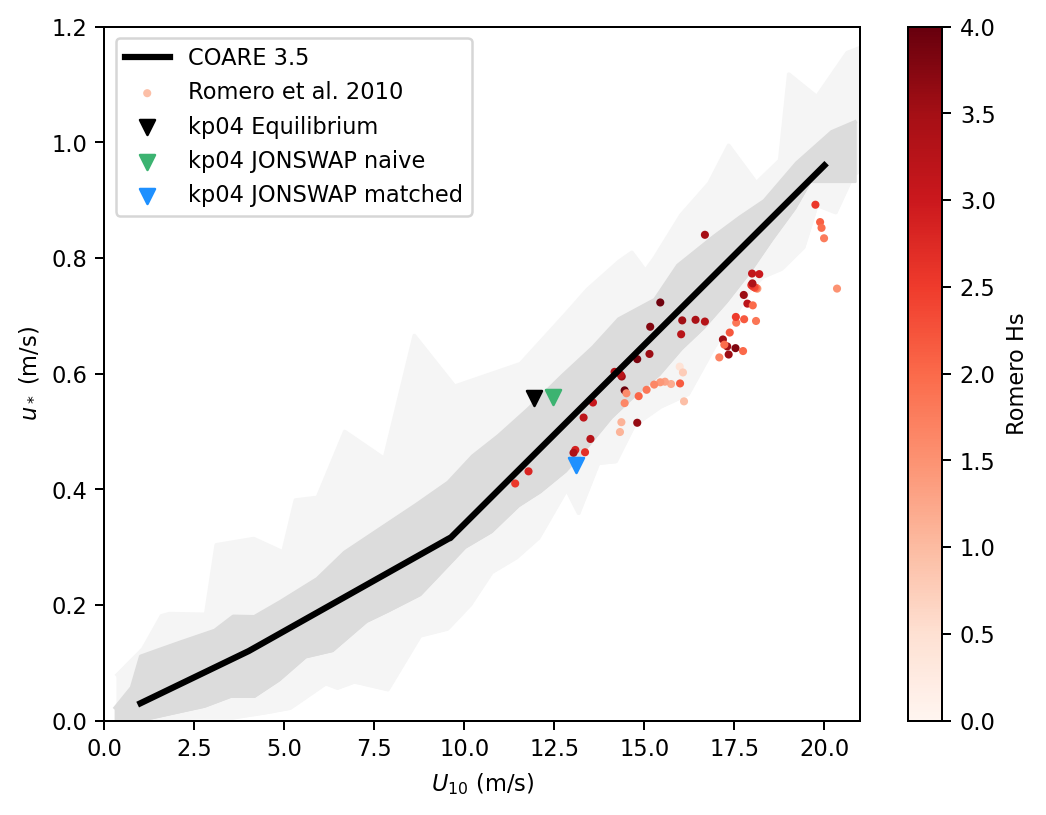

In [26]:
rcParams.update({'font.size': 9})
z_us = [2,100]

fig, ax = coare_plot_starter(figsize=(6,4.6), Romero_cmap='Reds')

hs_ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
hs_u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(statlist)):
    ax.scatter(hs_u10s[i], hs_ustars[i], c=colors[i], marker='v',
               label=ids[i], zorder=3)

ax.legend()